<a href="https://colab.research.google.com/github/AngeNana23/Final-Project/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://colab.research.google.com/drive/1pLLmCUYanVw773oA4biT4DDT7eEs7y5d?usp=sharing



      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0          EXP           758                 

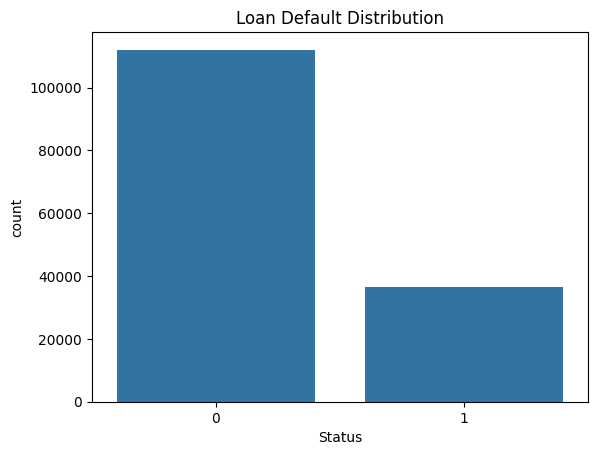

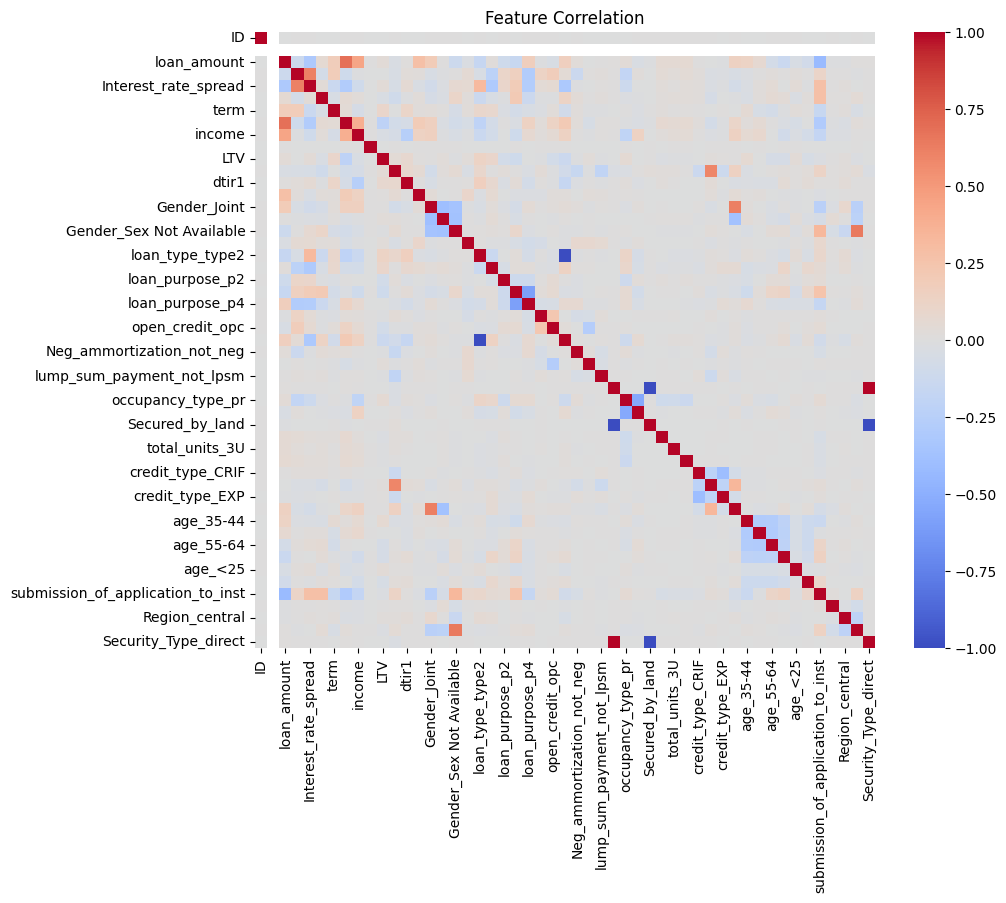

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Loan_Default.csv')

# Preview
print(df.head())
print(df.info())

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Visualization
sns.countplot(x='Status', data=df)
plt.title("Loan Default Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Split data
from sklearn.model_selection import train_test_split

X = df.drop('Status', axis=1)
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# 3. Model Selection and Development
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

# Random Forest (no scaling needed)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# 4. Model Evaluation and Optimization
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

print("Accuracy LR:", accuracy_score(y_test, y_pred_lr))
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logistic Regression:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00     22494
           1       0.24      1.00      0.39      7240

    accuracy                           0.24     29734
   macro avg       0.12      0.50      0.20     29734
weighted avg       0.06      0.24      0.10     29734

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       1.00      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

Accuracy LR: 0.24345866684603484
Accuracy RF: 1.0


In [15]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 50}


In [16]:
# 5. Model Deployment
def predict_default(model, input_data):
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df)
    return "Default" if prediction[0] == 1 else "No Default"

# Example input
sample = X_test.iloc[0].to_dict()
print(predict_default(rf, sample))

No Default
